# 03. GTX역 보행시간 구간분석 ⭐ 핵심 결과

**질문**: GTX-A역에 가까운 셀일수록 광역버스 승차가 더 많이 줄었나?

- 구간: **20분 이내 / 20~60분 / 60분 초과** (60분 초과 = 기준)
- 모형: 02와 같은 변화율 Poisson 모형에 구간 더미를 넣는다
- 강건성: ① 승차가 가장 많은 상위 5개 셀 제외, ② 20분 이내 셀을 하나씩 빼고 재추정, ③ 구간 기준을 10/15/20/30분으로 바꿔보기

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # 정리본 최상위의 config.py

from config import *
setup_notebook()

import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

data = load_model_data()  # data/processed/09_회귀분석_격자통합데이터.csv

,셀수,오전_2024,오전_2025,종일_2024,종일_2025,오전 변화율(%),종일 변화율(%)
walk_group,,,,,,,
20분 이내,11,1158.0,789.0,4282,2835,-31.9,-33.8
20~60분,74,4302.0,3463.0,13778,11602,-19.5,-15.8
60분 초과,47,584.0,505.0,1824,1863,-13.5,2.1


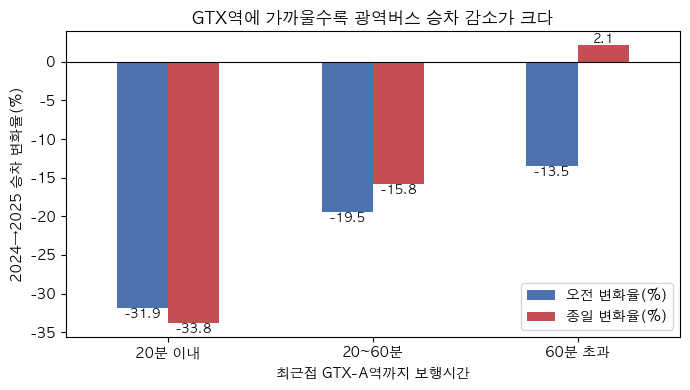

In [2]:
X_DUMMY = ["walk_20", "walk_20_60", "ic_access", "competing_share", "pop_20_50", "buildings"]

group = data.groupby("walk_group", observed=True).agg(
    셀수=("셀 ID", "size"), 오전_2024=("board_2024", "sum"), 오전_2025=("board_2025", "sum"),
    종일_2024=("board_2024_all", "sum"), 종일_2025=("board_2025_all", "sum"))
group["오전 변화율(%)"] = (group.오전_2025 / group.오전_2024 - 1) * 100
group["종일 변화율(%)"] = (group.종일_2025 / group.종일_2024 - 1) * 100
display(group.round(1))

ax = group[["오전 변화율(%)", "종일 변화율(%)"]].plot.bar(figsize=(7, 4), color=["#4C72B0", "#C44E52"], rot=0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("최근접 GTX-A역까지 보행시간")
ax.set_ylabel("2024→2025 승차 변화율(%)")
ax.set_title("GTX역에 가까울수록 광역버스 승차 감소가 크다")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=9)
plt.tight_layout()
plt.show()

## 구간 더미 회귀 (기준 = 60분 초과)

In [3]:
dummy = {
    "오전": rate_model(data, "board_2025", "board_2024", X_DUMMY),
    "종일": rate_model(data, "board_2025_all", "board_2024_all", X_DUMMY),
    "종일 (상위 5셀 제외)": rate_model(data.sort_values("board_2024_all").iloc[:-5], "board_2025_all", "board_2024_all", X_DUMMY),
}
pd.concat({name: coef_table(r, rate=True)[["변화율 차이(%)", "p", "유의"]] for name, r in dummy.items()}, axis=1)

오전                     종일              종일 (상위 5셀 제외)             
                 변화율 차이(%)       p   유의 변화율 차이(%)       p   유의     변화율 차이(%)       p   유의
const              39.2331  0.2545        33.4905  0.2034            31.8973  0.2418     
보행 20분 이내         -42.3252  0.0034  ***  -50.4714  0.0000  ***      -41.7862  0.0004  ***
보행 20~60분         -22.4820  0.1509       -28.8465  0.0134   **      -30.8585  0.0071  ***
IC까지 도로거리(km)      -8.8156  0.0039  ***   -5.1690  0.0248   **       -3.8765  0.0813    *
GTX 경쟁 목적지 비율(%)   -0.1096  0.7819        -0.4423  0.1108            -0.5748  0.0519    *
2024년 20~50대 인구     0.0110  0.3448         0.0190  0.0256   **        0.0120  0.1931     
2024년 건축물 수         0.1703  0.5699         0.0708  0.7029             0.0187  0.9272

→ 다른 조건이 같을 때, 20분 이내 셀은 60분 초과 셀보다 2025/2024 비율이 **약 40~50% 낮다**. 오전·종일 모두 p<0.01이다.

## 강건성 ② — 20분 이내 셀(11개)을 하나씩 빼고 재추정

In [4]:
near_cells = data.loc[data.walk_20 == 1, ["셀 ID", "nearest_station", "walk_min", "board_2024", "board_2025", "board_2024_all", "board_2025_all"]]
rows = []
for cell in near_cells["셀 ID"]:
    subset = data[data["셀 ID"] != cell]
    for label, (after, before) in {"오전": ("board_2025", "board_2024"), "종일": ("board_2025_all", "board_2024_all")}.items():
        r = rate_model(subset, after, before, X_DUMMY)
        rows.append({"뺀 셀": cell, "구분": label, "20분 이내 변화율 차이(%)": (np.exp(r.params["walk_20"]) - 1) * 100, "p": r.pvalues["walk_20"]})
loo = pd.DataFrame(rows).pivot(index="뺀 셀", columns="구분")
loo.columns = [f"{label} {stat}" for stat, label in loo.columns]
display(near_cells.set_index("셀 ID").join(loo).round(3))
print("한 셀씩 뺐을 때 p값 최댓값 — 오전: {:.4f}, 종일: {:.4f}".format(loo["오전 p"].max(), loo["종일 p"].max()))

,nearest_station,walk_min,board_2024,board_2025,board_2024_all,board_2025_all,오전 20분 이내 변화율 차이(%),종일 20분 이내 변화율 차이(%),오전 p,종일 p
셀 ID,,,,,,,,,,
3765,운정중앙,19.567,27.0,13.0,89,27,-41.984,-50.048,0.004,0.0
5217,운정중앙,8.852,258.0,161.0,619,440,-40.624,-50.173,0.005,0.0
7697,운정중앙,18.593,66.0,30.0,231,98,-41.186,-49.408,0.006,0.0
8546,대곡,19.825,1.0,4.0,9,14,-42.526,-50.586,0.003,0.0
8868,킨텍스,7.923,51.0,41.0,1036,424,-42.989,-43.266,0.003,0.0
11239,킨텍스,16.338,216.0,119.0,593,352,-40.128,-50.288,0.006,0.0
12765,킨텍스,3.553,235.0,228.0,882,945,-44.273,-53.817,0.001,0.0
13084,운정중앙,15.390,150.0,87.0,320,235,-42.231,-51.785,0.006,0.0
13602,운정중앙,17.828,58.0,23.0,135,34,-40.992,-49.277,0.006,0.0


한 셀씩 뺐을 때 p값 최댓값 — 오전: 0.0065, 종일: 0.0003


## 강건성 ③ — 역세권 기준을 바꿔보기 (기준 이내 vs 그 외)

In [5]:
rows = []
for cutoff in (10, 15, 20, 30, 40):
    frame = data.assign(near=(data.walk_min <= cutoff).astype(float))
    x_cols = ["near", "ic_access", "competing_share", "pop_20_50", "buildings"]
    for label, (after, before) in {"오전": ("board_2025", "board_2024"), "종일": ("board_2025_all", "board_2024_all")}.items():
        r = rate_model(frame, after, before, x_cols)
        rows.append({"기준(분)": cutoff, "셀 수": int(frame.near.sum()), "구분": label,
                     "변화율 차이(%)": (np.exp(r.params["near"]) - 1) * 100, "p": r.pvalues["near"]})
pd.DataFrame(rows).pivot(index=["기준(분)", "셀 수"], columns="구분", values=["변화율 차이(%)", "p"]).round(3)

변화율 차이(%)              p       
구분               오전      종일     오전     종일
기준(분) 셀 수                                
10    3     -16.678 -29.258  0.352  0.077
15    3     -16.678 -29.258  0.352  0.077
20    11    -26.442 -31.805  0.008  0.002
30    26    -13.961  -6.524  0.276  0.549
40    54    -20.311 -19.699  0.154  0.027

## 결론
- 보행시간이 짧을수록 감소가 커지는 **단계적 패턴**이 있다: 20분 이내 약 −33%, 20~60분 약 −16~20%, 60분 초과 −14%~+2%.
- **20분 이내 더미**는 상위 5셀 제외, 한 셀씩 빼기(11번 모두 p<0.01)에도 유지된다. → **현재 가장 탄탄한 결과**다.
- ⚠️ **기준 민감도**: '기준 이내 vs 그 외' 비교에서 계수 방향은 모든 기준에서 음(−)이다. 하지만 **유의한 건 20분 기준뿐**이다(30분 기준은 종일 −6.5%, p=0.55).
  - 즉 효과는 '역 바로 인근(20분 이내)'에 집중되어 있다. 또는 20분이라는 기준에 다소 민감할 수 있다.
  - → **07에서 노선 고정효과를 넣으면 15~60분 모든 기준에서 유의해진다.** 기준 민감도는 노선 구성 차이가 섞여서 생긴 문제였다. `07_노선효과_분리.ipynb` 참고.
- 한계: 20분 이내 셀이 11개뿐이다(운정중앙 6, 킨텍스 4, 대곡 1). 10·15분 기준은 셀이 3개라 해석하기 어렵다.